In [3]:
from typing import List
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
import numpy as np
import os


from qiskit import QuantumCircuit, generate_preset_pass_manager, transpile
from qiskit.circuit import  Parameter

#from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp


In [1]:
# To run on hardware, select the backend with the fewest number of jobs in the queue
service = QiskitRuntimeService(channel="ibm_quantum", token ="3b804182dcf5d92a78f5342e3c48bc71edd10a6e3a857928bd90f0c4fd2af986144fdb4b99551ef6c857b615e26a1186572c0aee4ec5d460427ca1884c7b5d26")
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
backend.name

NameError: name 'QiskitRuntimeService' is not defined

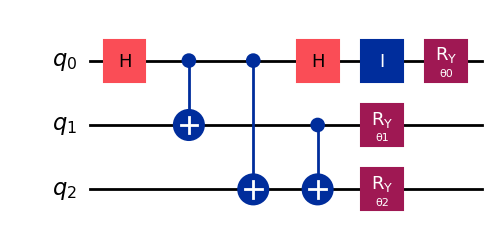

In [6]:
#circuit creation for GHZ state

ghz_circuit = QuantumCircuit(3)

# Create GHZ state
ghz_circuit.h(0)
ghz_circuit.cx(0, 1)
ghz_circuit.cx(0, 2)
ghz_circuit.h(0)
ghz_circuit.cx(1, 2)
ghz_circuit.id(0)

# Define measurement basis parameters
theta_0 = Parameter("θ0")  # Rotation for qubit 0
theta_1 = Parameter("θ1")  # Rotation for qubit 1
theta_2 = Parameter("θ2")  # Rotation for qubit 2

# Apply basis rotations
ghz_circuit.ry(theta_0, 0)
ghz_circuit.ry(theta_1, 1)
ghz_circuit.ry(theta_2, 2)
ghz_circuit.draw(output="mpl", idle_wires=False, style="iqp")

In [ ]:
# Rotations 

param_values_list = [
    [0, 0, np.pi / 2],  # ZZX
    [np.pi / 2, 0, np.pi / 2],  # ZXZ
    [np.pi / 2, 0, 0],  # XZZ
    [np.pi / 2, np.pi / 2, np.pi / 2]  #XXX
]

# param_values_ZZX = {theta_0: 0, theta_1: 0, theta_2: np.pi / 2}
# param_values_ZXZ = {theta_0: np.pi / 2, theta_1: 0, theta_2: np.pi / 2}
# param_values_XZZ = {theta_0: np.pi / 2, theta_1: 0, theta_2: 0}
# param_values_XXX = {theta_0: np.pi / 2, theta_1: np.pi / 2, theta_2: np.pi / 2}

In [ ]:
#Defining the observables using Mermin's Inequality 
observable1 = SparsePauliOp.from_list([
    ("YYX", 1),
    ("YXY", 1),
    ("XYY", 1),
    ("XXX", -1)
])
observable2 = SparsePauliOp.from_list([
    ("YYY", 1),
    ("XYX", -1),
    ("YXX", -1),
    ("XXY", -1)
])

In [ ]:

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

ghz_isa_circuit = pm.run(ghz_circuit)
ghz_isa_circuit.draw(output="mpl", idle_wires=False, style="iqp")

In [ ]:
isa_observable1 = observable1.apply_layout(layout=ghz_isa_circuit.layout)
isa_observable2 = observable2.apply_layout(layout=ghz_isa_circuit.layout)

In [ ]:
estimator = Estimator(mode=backend)

pub = (
    ghz_isa_circuit,  # ISA circuit
    [[isa_observable1],[isa_observable2]],  # ISA Observables
    param_values_list,  # Parameter values
)

job_result = estimator.run(pubs=[pub])
job = estimator.run(pubs=[pub])
print(job)
job_result = job.result()